# 🛠️ Proyecto ETL — Limpieza de Datos Tech
#### Módulo: Análisis de Datos · Somos F5 / Simplon

---

**¿Qué es un ETL?**

| Letra | Significa | En este proyecto |
|-------|-----------|------------------|
| **E** | Extract | Cargar el CSV con datos sucios |
| **T** | Transform | Limpiar, corregir y estandarizar |
| **L** | Load | Guardar el resultado limpio en un nuevo CSV |

---

### 🗂️ El dataset

Recibes el archivo `salarios_tech_sucio.csv` con **130 registros** de profesionales del sector tech.  
Los datos llegaron de un formulario web y tienen varios problemas que debes resolver.

### 🎯 Tu misión

Al final del proyecto deberás tener un archivo `salarios_tech_limpio.csv` con datos confiables y listos para analizar.

---

> 💡 **Cómo usar este notebook:**  
> Cada paso tiene una descripción, una pista (`💡 Pista`) y una celda vacía para tu código.  

---
## ⚙️ Setup

Importa las librerías necesarias para todo el proyecto.

In [108]:
import pandas as pd
import numpy as np

print('✅ Librerías importadas')
print('   pandas:', pd.__version__)
print('   numpy: ', np.__version__)



✅ Librerías importadas
   pandas: 2.2.2
   numpy:  2.0.2


---
# 📥 FASE E — EXTRACT
## Paso 1: Cargar el dataset

Sube el archivo `salarios_tech_sucio.csv` a tu sesión de Colab  
(panel izquierdo → icono de carpeta → subir archivo).

Luego cárgalo en un DataFrame llamado `df_raw`.

> ⚠️ **Importante:** guarda los datos originales en `df_raw` y **no los modifiques**.  
> Todo el trabajo de limpieza lo harás sobre una copia.

In [109]:
df_raw = pd.read_csv('salarios_tech_sucio.csv')

print(f'Dataset cargado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
df_raw.head(10)



Dataset cargado: 130 filas × 8 columnas


,nombre_rol,anios_experiencia,salario_anual_eur,pais,empresa_tipo,nivel,modalidad_trabajo,anio_registro
0,Data Scientist,99.0,34000.0,FR,Startup,Senior,Presencial,desconocido
1,Data Analyst,2.0,46000.0,US,Consultora,Junior,híbrido,2023
2,BI Developer,5.0,43000.0,es,Enterprise,Senior,híbrido,2023
3,Data Scientist,8.0,49000.0,NL,Consultora,Lead,Híbrido,2023
4,ML Engineer,12.0,NaN,es,Startup,Mid,remoto,2023
5,Data Analyst,10.0,52000.0,ES,PYME,Junior,NaN,2023
6,BI Developer,-1.0,40000.0,es,Consultora,NaN,Híbrido,2022
7,BI Developer,-1.0,28000.0,US,PYME,NaN,remoto,2022
8,Data Scientist,-1.0,82000.0,ES,Enterprise,SENIOR,remoto,2023
9,Data Engineer,99.0,55000.0,es,Startup,junior,híbrido,2021


---
## Paso 2: Diagnóstico inicial

Antes de limpiar, necesitas saber **exactamente qué hay que limpiar**.  
Responde estas preguntas usando código:

In [110]:
# 🔍 ¿Cuántas filas y columnas tiene el dataset?
# ¿Qué tipo de dato tiene cada columna?
# ¿Hay columnas con valores no nulos que deberían serlo?
# 💡 Pista: .info() te da todo esto de un golpe

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nombre_rol         130 non-null    object 
 1   anios_experiencia  121 non-null    float64
 2   salario_anual_eur  115 non-null    float64
 3   pais               130 non-null    object 
 4   empresa_tipo       130 non-null    object 
 5   nivel              109 non-null    object 
 6   modalidad_trabajo  113 non-null    object 
 7   anio_registro      130 non-null    object 
dtypes: float64(2), object(6)
memory usage: 8.3+ KB


In [111]:
# 🔍 ¿Cuántos valores nulos hay en cada columna? ¿Qué porcentaje representan?
nulos_totales=df_raw.isnull().sum()
porcentaje_nulos=nulos_totales/len(df_raw) * 100
resumen_nulos = pd.DataFrame({"nulos": nulos_totales, "porcentaje": porcentaje_nulos.round(2)})
resumen_nulos


,nulos,porcentaje
nombre_rol,0,0.00
anios_experiencia,9,6.92
salario_anual_eur,15,11.54
pais,0,0.00
empresa_tipo,0,0.00
nivel,21,16.15
modalidad_trabajo,17,13.08
anio_registro,0,0.00


<details><summary>💡 Pista</summary>

combina `.isnull().sum()` con una división por `len(df_raw)` y multiplica por 100
La salida esperada sería:

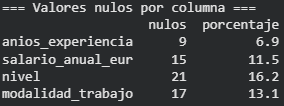

</details>

In [112]:
# 🔍 ¿Cuántas filas están duplicadas exactamente?


duplicados = df_raw.duplicated().sum()
duplicados

np.int64(10)

<details><summary>💡 Pista</summary>

`.duplicated().sum()`


La salida esperada:

**Filas duplicadas encontradas: 10**
</details>

In [113]:
# 🔍 Para las columnas 'pais', 'nivel' y 'modalidad_trabajo':
#    ¿Hay variantes del mismo valor escritas de forma diferente?
#    (detecta inconsistencias de capitalización)
# 💡 Pista: Un for iterando en las columnas y, además un .value_counts(dropna=False) en cada columna
columnas = ["pais", "nivel", "modalidad_trabajo"]

for columna in columnas:
  print(df_raw[columna].value_counts(dropna=False))

pais
ES    21
NL    19
FR    17
es    16
US    14
GB    12
DE    11
PT    11
Es     9
Name: count, dtype: int64
nivel
junior    22
NaN       21
Junior    20
Lead      20
Senior    19
Mid       15
SENIOR    13
Name: count, dtype: int64
modalidad_trabajo
híbrido       28
Remoto        27
remoto        24
Presencial    17
Híbrido       17
NaN           17
Name: count, dtype: int64


<details><summary>💡 Pista</summary>

La salida esperada sería:

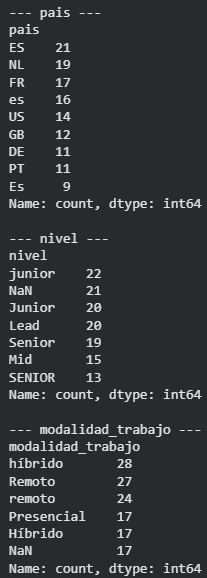
</details>

In [114]:
# 🔍 Mira las estadísticas de 'salario_anual_eur' y 'anios_experiencia'
#    ¿Ves valores que no tienen sentido en el mundo real?
# 💡 Pista: .describe() te muestra el mínimo y el máximo

print(df_raw[["salario_anual_eur", "anios_experiencia"]].describe(include="all"))

       salario_anual_eur  anios_experiencia
count         115.000000         121.000000
mean        94573.869565          14.330579
std        195549.856062          27.270066
min         -5000.000000          -1.000000
25%         37000.000000           3.000000
50%         52000.000000           7.000000
75%         77500.000000          10.000000
max        999999.000000          99.000000


## 📋 Resumen de problemas encontrados

| # | Problema | Columna(s) afectada(s) | Acción |
|---|----------|------------------------|--------|
| 1 | Filas duplicadas | Todo el dataset | `drop_duplicates()` |
| 2 | Valores nulos | `salario_anual_eur`, `nivel`, `modalidad_trabajo`, `anios_experiencia` | Rellenar o eliminar |
| 3 | Inconsistencias de capitalización | `pais`, `nivel`, `modalidad_trabajo` | `.str.upper()` / `.str.title()` |
| 4 | Outliers numéricos | `salario_anual_eur`, `anios_experiencia` | Filtrar rangos válidos |
| 5 | Tipos de dato incorrectos | `salario_anual_eur`, `anios_experiencia` | `pd.to_numeric()` |
| 6 | Valores inválidos en texto | `anio_registro` ('desconocido') | Reemplazar con `NaN` |

---
# 🔧 FASE T — TRANSFORM

⚠️ **Antes de empezar:** crea una copia del dataset original.  
Buena práctica: **trabajar siempre sobre una copia**, nunca modificar el original.  
Así podemos comparar el antes y el después al final.

In [115]:
# Crea una copia llamada 'df' a partir de df_raw
# 💡 Pista: .copy() crea una copia independiente (no una referencia)

df = df_raw.copy()
df

,nombre_rol,anios_experiencia,salario_anual_eur,pais,empresa_tipo,nivel,modalidad_trabajo,anio_registro
0,Data Scientist,99.0,34000.0,FR,Startup,Senior,Presencial,desconocido
1,Data Analyst,2.0,46000.0,US,Consultora,Junior,híbrido,2023
2,BI Developer,5.0,43000.0,es,Enterprise,Senior,híbrido,2023
3,Data Scientist,8.0,49000.0,NL,Consultora,Lead,Híbrido,2023
4,ML Engineer,12.0,NaN,es,Startup,Mid,remoto,2023
...,...,...,...,...,...,...,...,...
125,Data Analyst,5.0,43000.0,GB,PYME,Senior,NaN,2023
126,Data Scientist,12.0,NaN,es,Startup,junior,híbrido,2022
127,Data Analyst,15.0,46000.0,ES,Enterprise,NaN,Presencial,2022
128,MLOps Engineer,-1.0,37000.0,ES,Consultora,Junior,Presencial,desconocido


---
## Paso 3: Eliminar filas duplicadas

Hay filas que aparecen más de una vez en el dataset.  
Quédate solo con la primera aparición de cada fila.

In [116]:
# Elimina los duplicados de df
# Imprime cuántas filas había antes y cuántas quedan después
# 💡 Pista: .drop_duplicates() devuelve el DataFrame sin duplicados
#           Recuerda reasignar el resultado: df = df.drop_duplicates()

antes= len(df)
df = df.drop_duplicates()
despues = len(df)

print(f"Filas antes: {antes}")
print(f"Filas después: {despues}")
print(f"Filas eliminadas: {antes-despues}")


Filas antes: 130
Filas después: 120
Filas eliminadas: 10


<details><summary>💡 Pista</summary>

La salida esperada sería:

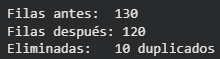
</details>

---
## Paso 4: Corregir tipos de dato

El CSV guarda todo como texto (`object`). Necesitas convertir las columnas numéricas a `float` o `int`.

Además, la columna `anio_registro` tiene el valor `'desconocido'` en algunas filas.  
Hay que reemplazarlo antes de convertir.

`errors='coerce'` convierte lo que no puede parsear en `NaN` en lugar de lanzar un error.  
Es la forma segura de hacer conversiones cuando los datos son sucios.

In [117]:
# Convierte 'salario_anual_eur' y 'anios_experiencia' a numérico
# 💡 Pista: pd.to_numeric(df['columna'], errors='coerce')
#           errors='coerce' convierte lo que no puede parsear en NaN (sin lanzar error)


# Verifica que los tipos cambiaron
print(df.dtypes)

salario_anual=df['salario_anual_eur']
anios_exp=df['anios_experiencia']

salario_anual=pd.to_numeric(salario_anual, errors='coerce')
anios_exp=pd.to_numeric(anios_exp, errors='coerce')

# Para 'anio_registro': primero reemplaza 'desconocido' por np.nan, luego convierte
# 💡 Pista: .replace('valor_viejo', valor_nuevo) y después pd.to_numeric()

anio_reg = df['anio_registro']
anio_reg=pd.to_numeric(anio_reg.replace('desconocido', np.nan), errors='coerce')

df.loc[:, 'salario_anual_eur'] = salario_anual
df.loc[:, 'anios_experiencia'] = anios_exp
df.loc[:, 'anio_registro'] = anio_reg


print("\n")
print(df.dtypes)



nombre_rol            object
anios_experiencia    float64
salario_anual_eur    float64
pais                  object
empresa_tipo          object
nivel                 object
modalidad_trabajo     object
anio_registro         object
dtype: object


nombre_rol            object
anios_experiencia    float64
salario_anual_eur    float64
pais                  object
empresa_tipo          object
nivel                 object
modalidad_trabajo     object
anio_registro         object
dtype: object


<details><summary>💡 Pista</summary>

La salida esperada sería:


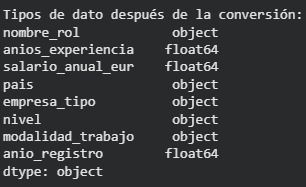

</details>

---
## Paso 5: Estandarizar capitalización

Hay valores que representan lo mismo pero están escritos diferente:  
`'ES'`, `'es'`, `'Es'` → todos son España.

Estandariza:
- `pais` → todo en **MAYÚSCULAS** (es un código de país)
- `nivel` y `modalidad_trabajo` → **formato título** (Primera Letra Mayúscula)

In [118]:
# Estandariza las tres columnas
# 💡 Pista: .str.strip() elimina espacios extra
#           .str.upper() pone todo en mayúsculas
#           .str.title() pone la primera letra de cada palabra en mayúscula
df.loc[:,"pais"]=df["pais"].str.strip().str.upper()
df.loc[:,"nivel"]=df["nivel"].str.strip().str.title()
df.loc[:,"modalidad_trabajo"]=df["modalidad_trabajo"].str.strip().str.title()

# Verifica: imprime los valores únicos de cada columna
# No debería haber más variantes del mismo valor

print("Valores únicos en país:", sorted(df["pais"].dropna().unique()))
print(f"Valores únicos en nivel:", sorted(df["nivel"].dropna().unique()))
print(f"Valores únicos en modalidad_trabajo:", sorted(df["modalidad_trabajo"].dropna().unique()))

Valores únicos en país: ['DE', 'ES', 'FR', 'GB', 'NL', 'PT', 'US']
Valores únicos en nivel: ['Junior', 'Lead', 'Mid', 'Senior']
Valores únicos en modalidad_trabajo: ['Híbrido', 'Presencial', 'Remoto']


<details><summary>💡 Pista</summary>

La salida esperada sería:


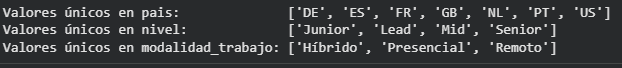

</details>

---
## Paso 6: Eliminar outliers

Hay valores numéricos que son técnicamente válidos pero **imposibles en la realidad**:
- Salarios de `999999`, `0` o `-5000` no son salarios reales
- Años de experiencia de `-1` o `99` no tienen sentido

En lugar de eliminar esas filas, **convierte esos valores a `NaN`**.  
Así la fila se conserva y el dato inválido se trata en el paso siguiente.

Rangos válidos que debes aplicar:
- Salario: entre **15,000€** y **300,000€**
- Años de experiencia: entre **0** y **40**

In [119]:

# Crea una máscara booleana para detectar los outliers de salario
# Luego asigna NaN donde la máscara sea True
# 💡 Pista: mask = (df['col'] < minimo) | (df['col'] > maximo)
#           df.loc[mask, 'col'] = np.nan
mask_salario = (df['salario_anual_eur'] < 15000) | (df['salario_anual_eur'] > 300000)
df.loc[mask_salario, 'salario_anual_eur'] = np.nan

# Haz lo mismo para anios_experiencia
# Años de experiencia: rango válido 0 – 40
# Valores como -1 o 99 son imposibles
mask_experiencia = (df['anios_experiencia'] < 0) | (df['anios_experiencia'] > 40)
df.loc[mask_experiencia, 'anios_experiencia'] = np.nan

# Imprime cuántos outliers convertiste en cada columna
print(f"Outliers salario convertidos a NaN: {mask_salario.sum()}")
print(f"Outliers experiencia convertidos a NaN: {mask_experiencia.sum()}")



Outliers salario convertidos a NaN: 12
Outliers experiencia convertidos a NaN: 25


<details><summary>💡 Pista</summary>

La salida esperada sería:

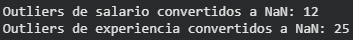

</details>

---
## Paso 7: Tratar los valores nulos

Ahora que ya corregiste los tipos y los outliers, es momento de decidir qué hacer con los `NaN`.

Hay dos estrategias principales. La elección depende del contexto:

| Estrategia | Cuándo usarla |
|------------|---------------|
| **Rellenar** (`fillna`) | Cuando podemos estimar un valor razonable (mediana, moda) |
| **Eliminar** (`dropna`) | Cuando la fila sin ese dato es inútil para el análisis |


Usa estas estrategias:
- **Columnas numéricas** (`salario_anual_eur`, `anios_experiencia`) → rellenar con la **mediana**
- **Columnas categóricas** (`nivel`, `modalidad_trabajo`) → rellenar con la **moda** (valor más frecuente)
- **`anio_registro`** → déjalo con NaN (no tenemos forma fiable de estimarlo)

In [129]:
# Rellena los nulos de las columnas numéricas con la mediana
# 💡 Pista: calcula la mediana con .median() y luego usa .fillna(valor)
#           Recuerda calcular la mediana ANTES de rellenar

mediana_salario=df['salario_anual_eur'].median()
mediana_exp=df['anios_experiencia'].median()

df.loc[:,'salario_anual_eur']=df['salario_anual_eur'].fillna(mediana_salario)
df.loc[:,'anios_experiencia']=df['anios_experiencia'].fillna(mediana_exp)

print(f"Salarios nulos rellenados: {mediana_salario}")
print(f"Experiencia nula rellenada: {mediana_exp}")


Salarios nulos rellenados: 55000.0
Experiencia nula rellenada: 7.0


<details><summary>💡 Pista</summary>

La salida esperada sería:

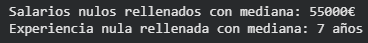


</details>

In [130]:
# Rellena los nulos de las columnas categóricas con la moda
# 💡 Pista: .mode() devuelve una Serie, necesitas el primer valor: .mode()[0]

moda_nivel=df['nivel'].mode()[0]
moda_mod_trabajo=df['modalidad_trabajo'].mode()[0]

df.loc[:,'nivel']=df['nivel'].fillna(moda_nivel)
df.loc[:,'modalidad_trabajo']=df['modalidad_trabajo'].fillna(moda_mod_trabajo)

print(f"Nivel nulo rellenado con moda: {moda_nivel}")
print(f"Modalidad nula rellenada con moda: {moda_mod_trabajo}")

Nivel nulo rellenado con moda: Junior
Modalidad nula rellenada con moda: Remoto


<details><summary>💡 Pista</summary>

La salida esperada sería:

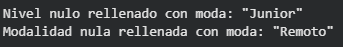

</details>

In [131]:
# Verifica: ¿quedan nulos en las columnas que debían quedar limpias?
# 💡 Pista: .isnull().sum()
print(df.isnull().sum())


nombre_rol            0
anios_experiencia     0
salario_anual_eur     0
pais                  0
empresa_tipo          0
nivel                 0
modalidad_trabajo     0
anio_registro        21
dtype: int64


<details><summary>💡 Pista</summary>

La salida esperada sería:

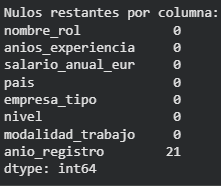


</details>

---
## Paso 8: Validación final

Antes de guardar, compara el dataset limpio con el original.  
Responde estas preguntas con código:

In [145]:
# Crea una comparativa que muestre:
#   - Filas antes y después
#   - Total de nulos antes y después
#   - Valores únicos en 'pais' antes y después
# 💡 Pista: usa df_raw para los valores 'antes' y df para los 'después'
#           .isnull().sum().sum() suma todos los nulos del DataFrame

#usare diccionario para agrupar las métricas en una sola estructura
compare = {

   "antes":[
       len(df_raw),
       int(df_raw.isnull().sum().sum()),
       df_raw["pais"].nunique(dropna=True)
   ],
   "despues":[
       len(df),
       int(df.isnull().sum().sum()),
       df["pais"].nunique(dropna=True)
   ]
}

antes=compare['antes']
despues=compare['despues']

print(f"Filas Originales: {antes[0]}")
print(f"Filas después de ETL: {despues[0]}")
print(f"Duplicados eliminados: {antes[0]-despues[0]}")
print("-----------------------------------------")
print(f"Nulos raw: {antes[1]}")
print(f"Nulos tras ETL: {despues[1]}")
print("-----------------------------------------")
print(f"Valores únicos en país (raw): {antes[2]}")
print(f"Valores únicos en país (ETL): {despues[2]}")


Filas Originales: 130
Filas después de ETL: 120
Duplicados eliminados: 10
-----------------------------------------
Nulos raw: 62
Nulos tras ETL: 21
-----------------------------------------
Valores únicos en país (raw): 9
Valores únicos en país (ETL): 7


<details><summary>💡 Pista</summary>

La salida esperada sería:



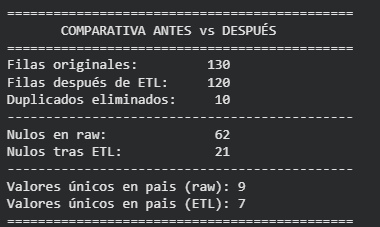

</details>

In [146]:
# Muestra las primeras 20 filas del dataset limpio

df.head(20)

,nombre_rol,anios_experiencia,salario_anual_eur,pais,empresa_tipo,nivel,modalidad_trabajo,anio_registro
0,Data Scientist,7.0,34000.0,FR,Startup,Senior,Presencial,NaN
1,Data Analyst,2.0,46000.0,US,Consultora,Junior,Híbrido,2023.0
2,BI Developer,5.0,43000.0,ES,Enterprise,Senior,Híbrido,2023.0
3,Data Scientist,8.0,49000.0,NL,Consultora,Lead,Híbrido,2023.0
4,ML Engineer,12.0,55000.0,ES,Startup,Mid,Remoto,2023.0
5,Data Analyst,10.0,52000.0,ES,PYME,Junior,Remoto,2023.0
6,BI Developer,7.0,40000.0,ES,Consultora,Junior,Híbrido,2022.0
7,BI Developer,7.0,28000.0,US,PYME,Junior,Remoto,2022.0
8,Data Scientist,7.0,82000.0,ES,Enterprise,Senior,Remoto,2023.0
9,Data Engineer,7.0,55000.0,ES,Startup,Junior,Híbrido,2021.0


---
# 💾 FASE L — LOAD
## Paso 9: Guardar el dataset limpio

El último paso del ETL: guardar el resultado en un nuevo archivo CSV.  
El archivo original no se toca. El nuevo archivo es el que usarás en análisis futuros.

In [147]:
# Guarda df como 'salarios_tech_limpio.csv'
# 💡 Pista: df.to_csv('nombre.csv', index=False, encoding='utf-8')
#           index=False evita que Pandas guarde la columna de índice numérico
archivo = 'salarios_tech_limpio.csv'

try:
  df.to_csv(archivo, index=False, encoding='utf-8')
except PermissionError:
  archivo='salarios_tech_limpio.csv'
  df.to_csv(archivo, index=False, encoding='utf-8')
  print('No se pudo sobrescribir el archivo original en este entorno; se guardó una copia alternativa.')

# Verifica que el archivo existe
import os
if os.path.exists('salarios_tech_limpio.csv'):
    size = os.path.getsize('salarios_tech_limpio.csv') / 1024
    print(f'✅ Archivo guardado correctamente ({size:.1f} KB)')
else:
    print('❌ El archivo no se encontró, revisa el paso anterior')

✅ Archivo guardado correctamente (6.9 KB)


---
## 🎁 Bonus: análisis sobre el dataset limpio

Si llegaste hasta aquí y sobra tiempo, responde estas preguntas usando el `df` limpio:

In [126]:
# ¿Cuál es el salario promedio por rol?
# 💡 Pista: .groupby('nombre_rol')['salario_anual_eur'].mean()



In [127]:
# ¿Qué modalidad de trabajo es la más común?



In [128]:
# ¿Cuál es el salario más alto del dataset? ¿A qué rol corresponde?



---
## ✅ Checklist de entrega

Antes de enviar tu notebook, confirma que completaste todo:

- [ ] El dataset se cargó correctamente en `df_raw`
- [ ] Completé la tabla de diagnóstico (Paso 2)
- [ ] Eliminé los duplicados (Paso 3)
- [ ] Corregí los tipos de dato (Paso 4)
- [ ] Estandaricé la capitalización (Paso 5)
- [ ] Eliminé los outliers convirtiéndolos a NaN (Paso 6)
- [ ] Rellené los nulos con mediana/moda (Paso 7)
- [ ] Hice la comparativa antes/después (Paso 8)
- [ ] Guardé el archivo `salarios_tech_limpio.csv` (Paso 9)
- [ ] Todas las celdas ejecutan sin errores

---

> 🚀 **¡Felicidades!** Completaste tu primer pipeline ETL con datos reales.  
> Este mismo patrón — Extract → Transform → Load — es la base de casi todo el trabajo en Análisis de Datos.